# K-최근접 이웃(K-Nearest Neighbor, KNN)
- 새로운 데이터가 주어졌을 때 기존 데이터 중 가장 가까운 K개의 데이터로 새로운 데이터를 예측하는 방법
- 지도학습 (거리 기반)
- 분류와 회귀 모두 사용 가능
    - 분류 모델 : `from sklearn.neighbors import KNeighborsClassifier`
    - 회귀 모델 : `from sklearn.neighbors import KNeighborsRegressor`
- 주요 파라미터
    - n_neighbors : 이웃 수

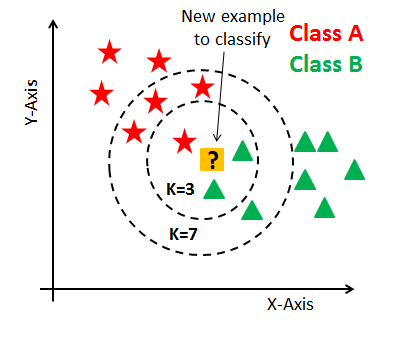

## 한글 폰트 설치 (Google Colab 사용 시)

그래프에서 한글이 깨지는 것을 방지합니다.  
아래 셀 실행 후 **런타임 → 세션 다시 시작** 을 눌러주세요.

In [ ]:
# Google Colab 환경에서만 실행
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [1]:
# (코드 실행)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# (코드 실행) 데이터 생성
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, random_state=0)
data = pd.DataFrame({
    'X1' : X[:, 0],
    'X2' : X[:, 1],
    'y' : y
})
data['y'] = data['y'].replace({0:'red', 1:'blue'})
data

,X1,X2,y
0,-0.766055,0.183325,red
1,-0.920383,-0.072317,red
2,-0.986585,-0.286920,red
3,1.709102,-1.104540,blue
4,1.987647,1.776245,blue
...,...,...,...
95,-0.989449,0.373436,red
96,-0.869385,-0.860700,red
97,2.530269,0.380252,blue
98,-0.461220,-3.697436,red


In [3]:
# (코드 실행) 새로운 데이터 생성
new_data = [[-0.5, 1.4]]
new_data

[[-0.5, 1.4]]

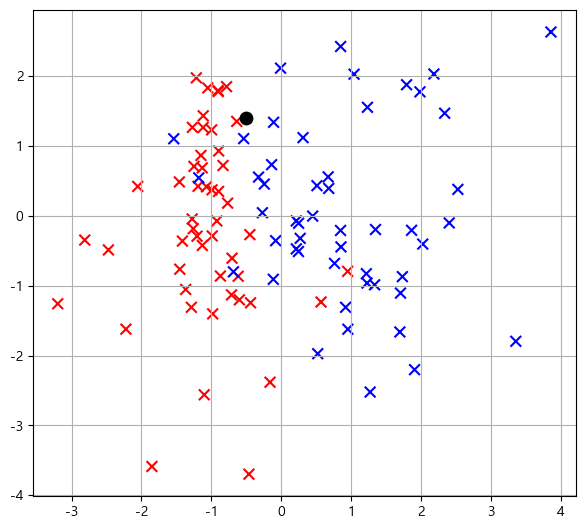

In [4]:
# (코드 실행) 데이터 시각화
plt.figure(figsize = (7,7))
plt.scatter('X1', 'X2', data=data, s=60, c='y', marker='x')
plt.scatter(new_data[0][0], new_data[0][1], color='k', s=80)
plt.gca().set_aspect('equal')
plt.grid()
plt.show()

<br/>
<br/>

### KNN 모델을 이용하여 기존 데이터 학습 및 새로운 데이터 예측하기
```python
from sklearn.neighbors import KNeighborsClassifier # 분류 모델
from sklearn.neighbors import KNeighborsRegressor # 회귀 모델
```
**Step1. 특성(Feature, X), 정답(Class, Label, y) 분리하기**
- 특성(X)은 **2차원** 자료구조
- 정답(y)은 **1차원** 자료구조

**Step2. 모델 생성**
```python
model = KNeighborsClassifier(n_neighbors = k)
```

**Step3. 생성된 모델에 데이터(X, y) 학습하기**
```python
model.fit(학습용 X, 학습용 y)
```

**Step4. 학습된 모델에 새로운 데이터 예측하기**
```python
model.predict(예측할 X)
```

In [5]:
# Step1. 특성(Feature, X), 정답(Class, Label, y) 분리하기
X = 
y = 
y

0      red
1      red
2      red
3     blue
4     blue
      ... 
95     red
96     red
97    blue
98     red
99     red
Name: y, Length: 100, dtype: object

In [6]:
# Step2. KNN 모델 생성 (n_neighbors = 3)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [7]:
# Step3. 생성된 모델에 데이터(X, y) 학습하기


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
# Step4. 학습된 모델에 새로운 데이터 예측하기


array(['blue'], dtype=object)

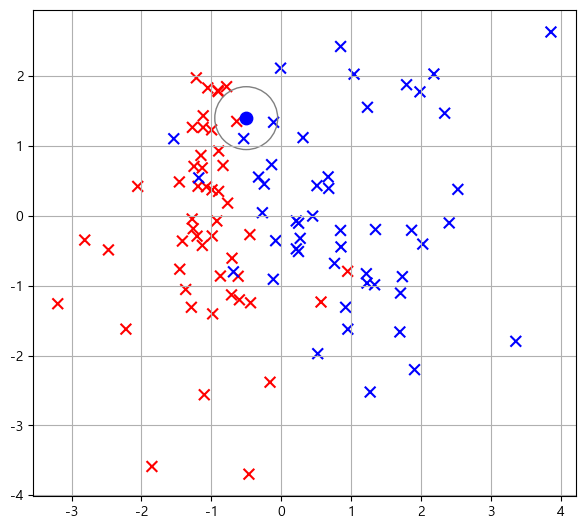

In [9]:
# (코드 실행) 예측 결과 시각화
plt.figure(figsize = (7,7))
plt.scatter('X1', 'X2', data=data, s=60, c='y', marker='x')
plt.scatter(new_data[0][0], new_data[0][1], color=model.predict(new_data), s=80)
circle=patches.Circle(new_data[0], radius=0.45, fill=False, edgecolor='gray')
plt.gca().add_patch(circle)
plt.gca().set_aspect('equal')
plt.grid()
plt.show()

<br/>
<br/>

### [연습문제]
- KNN 모델을 이용하여 새로운 데이터 예측하세요.
    - 새로운 데이터의 가장 근접한 5개의 데이터 관측하여 예측

In [10]:
# (코드 실행)
data

,X1,X2,y
0,-0.766055,0.183325,red
1,-0.920383,-0.072317,red
2,-0.986585,-0.286920,red
3,1.709102,-1.104540,blue
4,1.987647,1.776245,blue
...,...,...,...
95,-0.989449,0.373436,red
96,-0.869385,-0.860700,red
97,2.530269,0.380252,blue
98,-0.461220,-3.697436,red


In [11]:
# (코드 실행)
new_data

[[-0.5, 1.4]]

In [12]:
# Step1. 특성(Feature, X), 정답(Class, Label, y) 분리하기
X = 
y = 
X

,X1,X2
0,-0.766055,0.183325
1,-0.920383,-0.072317
2,-0.986585,-0.286920
3,1.709102,-1.104540
4,1.987647,1.776245
...,...,...
95,-0.989449,0.373436
96,-0.869385,-0.860700
97,2.530269,0.380252
98,-0.461220,-3.697436


In [13]:
# Step2. KNN 모델 생성 (n_neighbors = 5)
from sklearn.neighbors import KNeighborsClassifier
model = 
model

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
# Step3. 생성된 모델에 데이터(X, y) 학습하기


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [15]:
# Step4. 학습된 모델에 새로운 데이터 예측하기


array(['red'], dtype=object)

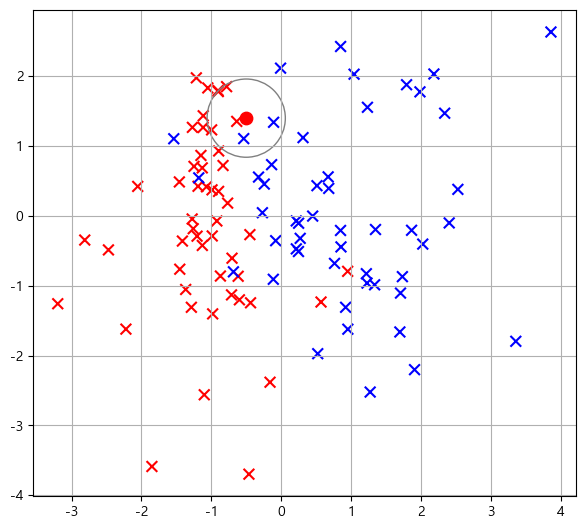

In [16]:
# (코드 실행) 예측 결과 시각화
plt.figure(figsize = (7,7))
plt.scatter('X1', 'X2', data=data, s=60, c='y', marker='x')
plt.scatter(new_data[0][0], new_data[0][1], color=model.predict(new_data), s=80)
circle=patches.Circle(new_data[0], radius=0.56, fill=False, edgecolor='gray')
plt.gca().add_patch(circle)
plt.gca().set_aspect('equal')
plt.grid()
plt.show()

<br/>
<br/>

### [연습문제]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [13]:
# "appleorange.csv" 파일을 로드하세요.
df = 
df

,무게,지름,종류
0,154.967142,7.162042,사과
1,148.617357,6.807459,사과
2,156.476885,6.661539,사과
3,165.230299,7.305838,사과
4,147.658466,7.515500,사과
...,...,...,...
95,136.254583,6.154127,오렌지
96,120.104394,5.646457,오렌지
97,119.436347,6.061490,오렌지
98,134.175533,6.023283,오렌지


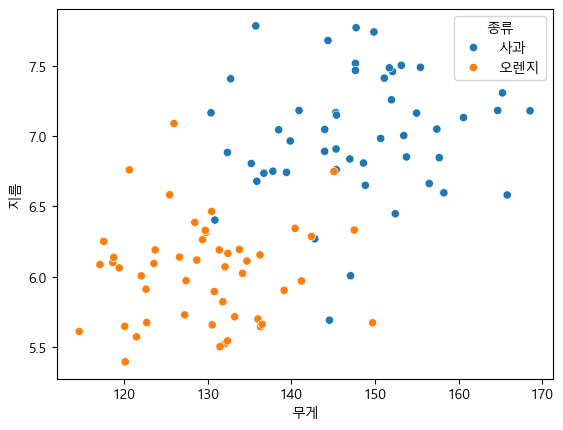

In [14]:
# 무게 별 지름을 산점도로 시각화하세요. - sns 이용, hue='종류'

plt.show()

In [16]:
# X에 무게, 지름 열, y에 종류 열을 저장하세요.
X = 
y = 
X.shape, y.shape

((100, 2), (100,))

In [17]:
# KNN 모델을 생성하세요.(n_neighbors=3)
from sklearn.neighbors import KNeighborsClassifier
model = 
model

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
# X, y 데이터를 학습하세요.


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [44]:
# (코드 실행) 새로운 과일의 무게, 지름 정보
new_samples = np.array([[140, 6.3],
                        [155, 7.2],
                        [130, 5.6]])
new_samples

array([[140. ,   6.3],
       [155. ,   7.2],
       [130. ,   5.6]])

In [45]:
# 위의 새로운 과일의 종류를 예측하세요.
pred = 
pred

C:\Users\user\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['사과', '사과', '오렌지'], dtype=object)

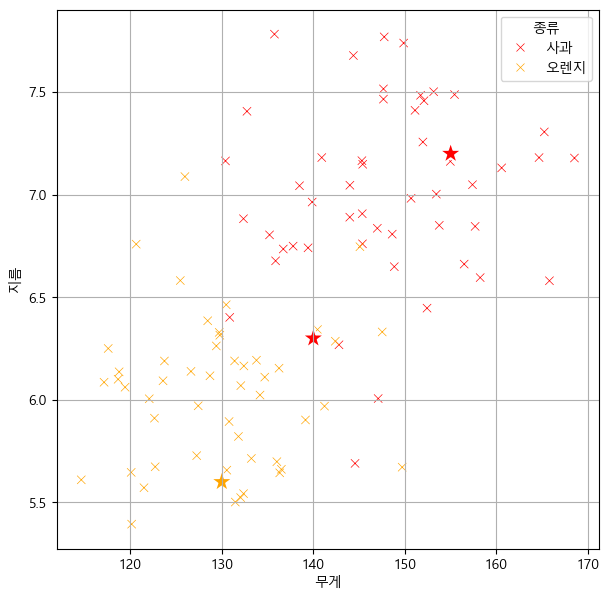

In [48]:
# (코드 실행) 예측 결과 시각화
plt.figure(figsize = (7,7))
sns.scatterplot(data=df, x='무게', y='지름', hue='종류',
                marker='x', palette={'사과':'red', '오렌지':'orange'})
sns.scatterplot(x=new_samples[:, 0], y=new_samples[:, 1], hue=pred,
                marker='*', s=300, palette={'사과':'red', '오렌지':'orange'},
                legend=False)
plt.grid()
plt.show()